In [11]:
from pathlib import Path
from collections import Counter
from PIL import Image
import numpy as np


# data sets download from https://www.kaggle.com/datasets/tongpython/cat-and-dog
base = "../../dataset/catvdog"
train_dir = Path(base+ "/training_set")
test_dir = Path(base + "/test_set")


IMAGE_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def explain_data_sets(root):
    widths, heights = [],[]
    modes, per_class= Counter(), Counter()
    bad = []
    
    for p in root.rglob("*"):
        if p.suffix.lower() not in IMAGE_EXT:
            continue
        try:
            with Image.open(p) as im:
                w,h = im.size
                widths.append(w)
                heights.append(h)
                modes[im.mode] += 1
            per_class[p.parent.name] += 1
        except Exception as e:
            bad.append((p.name, repr(e)))
    
    widths = np.array(widths)
    heights = np.array(heights)
    ratios = widths/heights

    
    print(f"total readble:{len(widths)}, total underadable:{len(bad)}")
    print("ureadable:", len(bad), bad[:5])
    print("per_class:", per_class)
    print("modes:", modes)
    stats("widths", widths)
    stats("heights", heights)
    stats("ratios", ratios)
    
    print("distinct sizes", len(set(zip(widths.tolist(), heights.tolist()))))
    print("extreme ratios", int(((ratios < 0.5) | (ratios > 2.0)).sum()))


def stats(name, a):
    print(f"name={name:8},min={a.min():.2f},p10={np.percentile(a,10):.2f} " + 
         f"median={np.median(a):.2f}, max={a.max():.2f}")



explain_data_sets(train_dir)
explain_data_sets(test_dir)


total readble:8005, total underadable:0
ureadable: 0 []
per_class: Counter({'dogs': 4005, 'cats': 4000})
modes: Counter({'RGB': 8005})
name=widths  ,min=57.00,p10=240.00 median=445.00, max=1050.00
name=heights ,min=41.00,p10=225.00 median=374.00, max=768.00
name=ratios  ,min=0.38,p10=0.75 median=1.27, max=2.84
distinct sizes 3529
extreme ratios 75
total readble:2023, total underadable:0
ureadable: 0 []
per_class: Counter({'dogs': 1012, 'cats': 1011})
modes: Counter({'RGB': 2023})
name=widths  ,min=59.00,p10=242.00 median=448.00, max=500.00
name=heights ,min=33.00,p10=224.00 median=374.00, max=500.00
name=ratios  ,min=0.42,p10=0.75 median=1.28, max=5.91
distinct sizes 1139
extreme ratios 12


In [12]:
SIZE = 64
CLASSES = ["cats", "dogs"]
LABEL_OF = {c: i for i, c in enumerate(CLASSES)}

def load_data_set(root):
    root = Path(root)
    images, labels = [], []

    for p in sorted(root.rglob("*")):
        if p.suffix.lower() not in IMAGE_EXT:
            # print(f" name:{p.name}")
            continue
        if p.parent.name not in LABEL_OF:
            continue

        with Image.open(p) as im:
            im = im.convert("RGB").resize((SIZE,SIZE), Image.BILINEAR)

        images.append(np.asarray(im, dtype=np.uint8))
        labels.append(LABEL_OF[p.parent.name])

    X = np.stack(images)
    Y = np.array(labels, dtype=np.int64)

    return X, Y
    

In [13]:
def flatten(X):
    return X.reshape(X.shape[0],-1).T / 255


def prepare_data_set():
    X_train_orig_set, Y_train_orig_set = load_data_set(train_dir)
    X_test_orig_set, Y_test_orig_set = load_data_set(test_dir)
    
    # print(X_train_orig_set.shape, Y_train_orig_set.shape)
    # print(X_test_orig_set.shape, Y_test_orig_set.shape)
    
    # Reshuffle the datasets  (since we ordered it previously)
    rng = np.random.default_rng(0)
    perm = rng.permutation(len(Y_train_orig_set))
    permtest = rng.permutation(len(Y_test_orig_set))
    
    X_train_orig_set, Y_train_orig_set = X_train_orig_set[perm], Y_train_orig_set[perm]
    X_test_orig_set, Y_test_orig_set = X_test_orig_set[permtest], Y_test_orig_set[permtest]

    # Flatten the data sets for the model.
    X_train = flatten(X_train_orig_set)
    X_test = flatten(X_test_orig_set)
    
    Y_train = Y_train_orig_set.reshape(1, -1)
    Y_test = Y_test_orig_set.reshape(1,-1)

    datasets =  {
        "X_train": X_train,
        "X_test": X_test,
        "Y_train": Y_train,
        "Y_test": Y_test,
        "X_train_orig_set": X_train_orig_set,
        "Y_train_orig_set": Y_train_orig_set,
        "X_test_orig_set": X_test_orig_set,
        "Y_test_orig_set": Y_test_orig_set
    }
    return datasets
    

In [14]:
datasets = prepare_data_set()

Y_train = datasets["Y_train"]
X_train = datasets ["X_train"]
X_test = datasets["X_test"]
Y_test = datasets["Y_test"]
X_test_orig_set = datasets["X_test_orig_set"]
X_train_orig_set = datasets["X_train_orig_set"]
assert X_train.shape == (SIZE * SIZE * 3, Y_train.shape[1])
assert set(np.unique(Y_train)) <= {0,1}


In [43]:
print(f"X_train.shape={X_train.shape}")


X_train.shape=(12288, 8005)


0.00392156862745098 1.0 0.45489493974673206 float64
uint8 0 255
0.0 1.0 float64


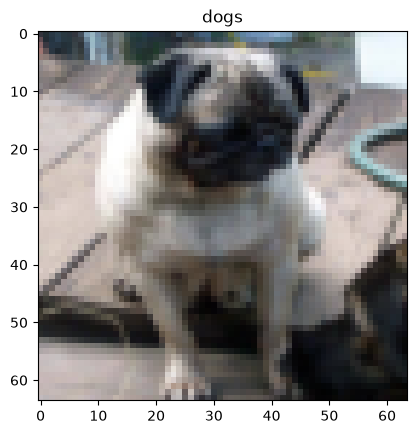

In [39]:
import matplotlib.pyplot as plt

i = 7
col = X_train[:, i]
print(col.min(), col.max(), col.mean(), col.dtype)
plt.imshow(X_train[:,i].reshape(SIZE, SIZE,3))
plt.title(CLASSES[Y_train[0,i]])

print(X_train_orig_set.dtype, X_train_orig_set.min(), X_train_orig_set.max())
print(X_train.min(), X_train.max(), X_train.dtype)

In [15]:
def sigmoid(z):
    s = 1  / (1 + np.exp(-z))
    return s

In [16]:
# test sigmoid
def sigmoid_test(target):
    x = np.array([0,2])
    output = target(x)

    assert type (output) == np.ndarray, "Wrong data type. Expected np.ndarray"
    assert np.allclose(output, [0.5, 0.88079708]), f"Wrong value. {output} != [0.5, 0.88079708]"
    output = target(1)
    assert np.allclose(output, 0.7310585), f"Wrong Value. {output} != 0.7310585"
    print('\033[92mAll tests passed!')
    
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid_test(sigmoid)

sigmoid([0, 2]) = [0.5        0.88079708]
All tests passed!


In [18]:
def propagate(w, b, x):
    z = np.dot(w.T, x) + b
    return z


def predict(z):
    return sigmoid(z)


def calculate_cost(a,y):
    return -y * np.log(a) - (1 - y) * np.log(1 - a)


In [19]:
def forward_pass(w,b,X_train, Y_train):
    m = X_train.shape[1]
    z = propagate(w,b,X_train)
    a = predict(z)

    cost = np.sum((calculate_cost(a, Y_train))) / m
    return a,cost
    
    

In [20]:
def backward_pass(a, X_train, Y_train):
    m = X_train.shape[1]
    dw = np.dot( X_train, (a-Y_train).T) / m
    db = np.sum((a-Y_train))/m

    return dw,db

In [22]:
w, b = initialize_with_zeros(X_train.shape[0])
a,cost = forward_pass(w,b,X_train, Y_train)
dw,db = backward_pass(a, X_train, Y_train)

print(f"a={a}, cost={cost}, dw={dw.shape}, db={np.shape(db)}")

a=[[0.5 0.5 0.5 ... 0.5 0.5 0.5]], cost=0.6931471805599454, dw=(12288, 1), db=()


In [23]:
def classify(w,b,X):
    z = propagate(w,b,X)
    a = predict(z)
    return (a > 0.5).astype(int) 

In [24]:
def initialize_with_zeros(dim):
    w,b = np.zeros((dim,1)), 0.0

    assert w.shape == (dim, 1)
    return w,b

In [31]:
def model(X_train, Y_train, X_test, Y_test, learning_rate = 0.01, iteration=200):

    # Initialize the weights and bias
    w,b = initialize_with_zeros(X_train.shape[0])
    costs = []
    for i in range(1,iteration+1):
        prediction, cost = forward_pass(w, b, X_train, Y_train)
        dw,db = backward_pass(prediction, X_train, Y_train)

        # adjust the weights and bias
        w = w - (learning_rate * dw)
        b = b - (learning_rate * db)
        
        if i % 1000 == 0:
            costs.append(cost)
            print(f"iter:{i}, cost: {cost}")

    
    # weights and bias finalized after the iteration
    # final clasification with training data set
    Y_prediction_train = classify(w,b,X_train)
    # comparison result with test data set
    Y_prediction_test = classify(w,b,X_test)

    train_acc = 100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
    test_acc = 100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
    print(f"train_accuracy: {train_acc}%")
    print(f"test_accuracy: {test_acc}%")

    
    d = {
        "w": w, 
        "b": b, 
        "costs": costs,
        "train_acc": train_acc,
        "test_acc": test_acc
    }

    return d


In [32]:
logistic_regression_model = model(X_train, Y_train, X_test, Y_test, learning_rate=0.001, iteration=5000)


iter:1000, cost: 0.6609453952926867
iter:2000, cost: 0.6529107668953266
iter:3000, cost: 0.6473806575971005
iter:4000, cost: 0.6428510839854299
iter:5000, cost: 0.6389290829212888
train_accuracy: 63.635227982510926%
test_accuracy: 61.097380128522%


y = 1, prediction: "dogs" picture.


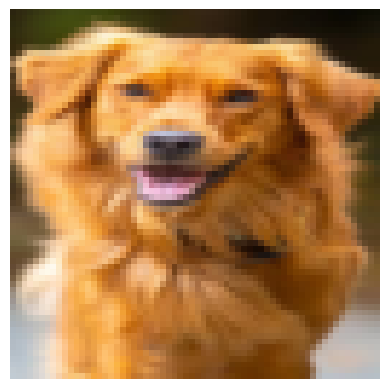

In [42]:
my_image = "cute_dog.jpeg"
fname = "../../test-dataset/images/" + my_image

img = Image.open(fname).convert("RGB").resize((SIZE, SIZE), Image.BILINEAR)
image = np.asarray(img, dtype=np.uint8)

plt.imshow(image)
plt.axis("off")

x = image.reshape(1, SIZE * SIZE * 3).T / 255.0

pred = classify(logistic_regression_model["w"], logistic_regression_model["b"], x)
label = int(np.squeeze(pred))
print(f'y = {label}, prediction: "{CLASSES[label]}" picture.')

y = 0, prediction: "cats" picture.


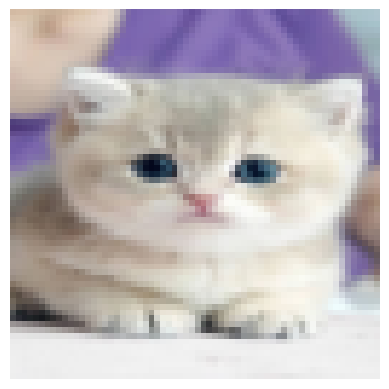

In [45]:
my_image = "cute_cat.jpg"
fname = "../../test-dataset/images/" + my_image

img = Image.open(fname).convert("RGB").resize((SIZE, SIZE), Image.BILINEAR)
image = np.asarray(img, dtype=np.uint8)

plt.imshow(image)
plt.axis("off")

x = image.reshape(1, SIZE * SIZE * 3).T / 255.0

pred = classify(logistic_regression_model["w"], logistic_regression_model["b"], x)
label = int(np.squeeze(pred))
print(f'y = {label}, prediction: "{CLASSES[label]}" picture.')